# Clasificación de Anorexia con LLMs Locales (Ollama)

Comparativa de **tres modos de prompting** con tres modelos LLM corriendo localmente:

| Modo | Descripción |
|------|-------------|
| `zero_shot` | Solo el tweet, sin ningún contexto adicional |
| `zero_shot_ctx` | Tweet + descripción del dataset y patrones clínicos |
| `few_shot` | Tweet + 2 ejemplos etiquetados por clase del set de entrenamiento |

Los resultados se cachean en `resultados_zeroshot/` por modo y modelo.

**Requisito:** `ollama serve` corriendo en la terminal.

In [1]:
import os
import re
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_curve, auc, classification_report
)

MODELOS       = ["phi3", "qwen2.5-coder:7b", "gemma2:2b"]
MODOS         = ["zero_shot", "zero_shot_ctx", "few_shot"]
OLLAMA_URL    = "http://localhost:11434/api/generate"
ARCHIVO_TEST  = "data_test_combined_limpio.csv"
ARCHIVO_TRAIN = "data_train.xlsx"
CACHE_DIR     = "resultados_zeroshot"
EJEMPLOS_POR_CLASE = 2   # para few-shot
SEED = 42
os.makedirs(CACHE_DIR, exist_ok=True)

try:
    requests.get("http://localhost:11434/", timeout=5)
    print("Ollama activo.")
except Exception:
    print("AVISO: Ollama no responde. Ejecuta 'ollama serve' antes de continuar.")

Ollama activo.


In [2]:
import ftfy

# Test set
df_test = pd.read_csv(ARCHIVO_TEST, encoding='latin1')
df_test['texto_llm'] = df_test['tweet_text_clean'].fillna("").astype(str).str.strip()
df_test = df_test[df_test['texto_llm'] != ""].reset_index(drop=True)
print(f"Test set: {len(df_test)} tweets")
print(df_test['class'].value_counts())

# Training set — solo para los ejemplos del few-shot
df_train = pd.read_excel(ARCHIVO_TRAIN)
df_train['texto_limpio'] = df_train['tweet_text'].apply(
    lambda t: ftfy.fix_text(str(t)).strip() if pd.notna(t) else ""
)
df_train = df_train[df_train['texto_limpio'] != ""]

# Seleccionar ejemplos representativos (sin tweets muy cortos)
df_train_filtrado = df_train[df_train['texto_limpio'].str.len() > 40]
ej_anorexia = (
    df_train_filtrado[df_train_filtrado['class'] == 'anorexia']
    .sample(EJEMPLOS_POR_CLASE, random_state=SEED)['texto_limpio'].tolist()
)
ej_control = (
    df_train_filtrado[df_train_filtrado['class'] == 'control']
    .sample(EJEMPLOS_POR_CLASE, random_state=SEED)['texto_limpio'].tolist()
)

print(f"\nEjemplos few-shot seleccionados del set de entrenamiento:")
for i, t in enumerate(ej_anorexia):
    print(f"  [anorexia {i+1}]: {t[:80]}...")
for i, t in enumerate(ej_control):
    print(f"  [control  {i+1}]: {t[:80]}...")

Test set: 375 tweets
class
anorexia    201
control     174
Name: count, dtype: int64

Ejemplos few-shot seleccionados del set de entrenamiento:
  [anorexia 1]: Extraño tener ojeras, las manos blancas & siempre frías...
#ProAna...
  [anorexia 2]: Enserio dejarnos em paz! Son nuestras vidas... Si quiero ser  lo sere,paren de c...
  [control  1]: Come sano, come fresco y atención con todo lo que leemos por ahi, si?

 #comerco...
  [control  2]: A veces el placer de comer se encuentra en los contrastes de aromas y sabores en...


In [3]:
# ── Modo 1: Zero-Shot ────────────────────────────────────────────────
PROMPT_ZERO_SHOT = """Analiza este tweet en español y determina si la persona muestra indicadores de anorexia o trastorno alimentario.

Tweet: \"{tweet}\"

Responde ÚNICAMENTE con este formato exacto, sin texto adicional:
Clase: [anorexia o control]
Probabilidad_anorexia: [número entre 0.0 y 1.0]"""


# ── Modo 2: Zero-Shot + Contexto del dataset ─────────────────────────
PROMPT_ZERO_SHOT_CTX = """Eres un sistema experto en detección de trastornos de la conducta alimentaria (TCA) en redes sociales.

Contexto del dataset:
- Tweets en español recopilados de Twitter/X, etiquetados manualmente por expertos clínicos.
- Clase 'anorexia': tweets que expresan restricción calórica deliberada, miedo intenso a ganar peso, distorsión de la imagen corporal, idealización de la delgadez, ayunos, uso de términos como #hastaloshuesos o #thinspo, autorreproche por comer, aislamiento social relacionado con comida.
- Clase 'control': contenido cotidiano sin indicadores de TCA — noticias, entretenimiento, vida diaria, alimentación equilibrada.

Tweet a clasificar: \"{tweet}\"

Responde ÚNICAMENTE con este formato exacto, sin texto adicional:
Clase: [anorexia o control]
Probabilidad_anorexia: [número entre 0.0 y 1.0]"""


# ── Modo 3: Few-Shot ─────────────────────────────────────────────────
def construir_prompt_few_shot(tweet, ej_anorexia, ej_control):
    bloques = []
    for i, t in enumerate(ej_anorexia):
        bloques.append(
            f'Ejemplo {i+1}:\nTweet: "{t[:200]}"\nClase: anorexia\nProbabilidad_anorexia: 0.90'
        )
    for i, t in enumerate(ej_control):
        bloques.append(
            f'Ejemplo {i+1+len(ej_anorexia)}:\nTweet: "{t[:200]}"\nClase: control\nProbabilidad_anorexia: 0.10'
        )
    ejemplos_str = "\n\n".join(bloques)
    return f"""Eres un sistema experto en detección de trastornos de la conducta alimentaria en redes sociales.

A continuación hay ejemplos reales del dataset con su clasificación correcta:

{ejemplos_str}

Ahora clasifica el siguiente tweet aplicando el mismo criterio:
Tweet: \"{tweet}\"

Responde ÚNICAMENTE con este formato exacto, sin texto adicional:
Clase: [anorexia o control]
Probabilidad_anorexia: [número entre 0.0 y 1.0]"""


def construir_prompt(modo, tweet, **kwargs):
    if modo == "zero_shot":
        return PROMPT_ZERO_SHOT.format(tweet=tweet[:450])
    elif modo == "zero_shot_ctx":
        return PROMPT_ZERO_SHOT_CTX.format(tweet=tweet[:450])
    elif modo == "few_shot":
        return construir_prompt_few_shot(tweet[:350], kwargs['ej_a'], kwargs['ej_c'])


print("Prompts definidos para los 3 modos.")

Prompts definidos para los 3 modos.


In [4]:
def llamar_ollama(modelo, prompt, timeout=120):
    try:
        resp = requests.post(
            OLLAMA_URL,
            json={
                "model": modelo,
                "prompt": prompt,
                "stream": False,
                "options": {"temperature": 0, "num_predict": 60}
            },
            timeout=timeout
        )
        resp.raise_for_status()
        return resp.json().get("response", "")
    except Exception as e:
        return f"ERROR:{e}"


def parsear_respuesta(respuesta):
    texto = respuesta.lower().strip()
    clase = None
    prob  = None

    for linea in texto.split('\n'):
        if 'clase:' in linea:
            if 'anorexia' in linea:
                clase = 'anorexia'
            elif 'control' in linea:
                clase = 'control'
        if 'probabilidad_anorexia:' in linea or 'probabilidad anorexia:' in linea:
            match = re.search(r'(\d+\.?\d*)', linea.split(':', 1)[-1])
            if match:
                prob = min(max(float(match.group(1)), 0.0), 1.0)

    if clase is None:
        resto = '\n'.join(texto.split('\n')[1:])
        clase = 'anorexia' if resto.count('anorexia') > resto.count('control') else 'control'

    if prob is None:
        prob = 0.80 if clase == 'anorexia' else 0.20

    if clase == 'control' and prob > 0.5:
        prob = 1.0 - prob

    return clase, prob


print("Funciones de API y parseo listas.")

Funciones de API y parseo listas.


In [5]:
# Clasificación para todos los modos × modelos (con cache)
resultados = {}   # resultados[modo][modelo] = DataFrame

_ETIQUETAS = {
    'zero_shot':     'Zero-Shot',
    'zero_shot_ctx': 'Zero-Shot + Contexto',
    'few_shot':      'Few-Shot',
}

for modo in MODOS:
    resultados[modo] = {}
    etiqueta = _ETIQUETAS[modo]
    linea = '─' * (len(etiqueta) + 4)
    print(f'\n{linea}')
    print(f'  MODO: {etiqueta}')
    print(linea)

    for modelo in MODELOS:
        cache_path = f"{CACHE_DIR}/{modo}__{modelo.replace(':', '_').replace('/', '_')}.csv"

        if os.path.exists(cache_path):
            print(f"  [cache] {modelo}")
            resultados[modo][modelo] = pd.read_csv(cache_path)
            continue

        print(f"\n  → Clasificando: {modelo}")
        preds, probs = [], []
        inicio = time.time()

        for i, row in df_test.iterrows():
            prompt = construir_prompt(
                modo, row['texto_llm'],
                ej_a=ej_anorexia, ej_c=ej_control
            )
            respuesta = llamar_ollama(modelo, prompt)
            clase, prob = parsear_respuesta(respuesta)
            preds.append(clase)
            probs.append(prob)

            if (i + 1) % 50 == 0:
                print(f"     {i+1}/{len(df_test)} | {(time.time()-inicio)/60:.1f} min")

        df_res = df_test[['class', 'texto_llm']].copy()
        df_res['prediccion']    = preds
        df_res['prob_anorexia'] = probs
        df_res.to_csv(cache_path, index=False)
        resultados[modo][modelo] = df_res
        print(f"     Guardado: {cache_path} | {(time.time()-inicio)/60:.1f} min total")

print("\nClasificación completa para todos los modos y modelos.")


─────────────
  MODO: Zero-Shot
─────────────
  [cache] phi3

  → Clasificando: qwen2.5-coder:7b
     50/375 | 0.3 min
     100/375 | 0.6 min
     150/375 | 0.9 min
     200/375 | 1.2 min
     250/375 | 1.6 min
     300/375 | 1.9 min
     350/375 | 2.2 min
     Guardado: resultados_zeroshot/zero_shot__qwen2.5-coder_7b.csv | 2.4 min total

  → Clasificando: gemma2:2b
     50/375 | 0.2 min
     100/375 | 0.4 min
     150/375 | 0.6 min
     200/375 | 0.7 min
     250/375 | 0.9 min
     300/375 | 1.1 min
     350/375 | 1.2 min
     Guardado: resultados_zeroshot/zero_shot__gemma2_2b.csv | 1.3 min total

────────────────────────
  MODO: Zero-Shot + Contexto
────────────────────────

  → Clasificando: phi3
     50/375 | 0.2 min
     100/375 | 0.5 min
     150/375 | 0.7 min
     200/375 | 0.9 min
     250/375 | 1.1 min
     300/375 | 1.3 min
     350/375 | 1.6 min
     Guardado: resultados_zeroshot/zero_shot_ctx__phi3.csv | 1.7 min total

  → Clasificando: qwen2.5-coder:7b
     50/375 | 0.3 m

In [6]:
from sklearn.metrics import precision_score

def imprimir_tabla(filas, encabezados, titulo=None):
    anchos = [len(str(h)) for h in encabezados]
    for fila in filas:
        for i, val in enumerate(fila):
            anchos[i] = max(anchos[i], len(str(val)))
    anchos = [a + 2 for a in anchos]

    ancho_total = sum(anchos) + len(anchos) + 1

    def sep(izq, mid, der, rel='─'):
        return izq + mid.join(rel * a for a in anchos) + der

    def fila_str(vals):
        return '│' + '│'.join(f' {str(v):<{a-2}} ' for v, a in zip(vals, anchos)) + '│'

    if titulo:
        linea = '─' * max(ancho_total, len(titulo) + 4)
        print(f'\n{linea}')
        print(f'  {titulo}')
        print(linea)

    print(sep('┌', '┬', '┐'))
    print(fila_str(encabezados))
    print(sep('├', '┼', '┤'))
    for i, fila in enumerate(filas):
        print(fila_str(fila))
        if i < len(filas) - 1:
            print(sep('├', '┼', '┤'))
    print(sep('└', '┴', '┘'))


# Calcular métricas para todos los modos × modelos
metricas = {}

ETIQUETAS_MODO = {
    'zero_shot':     'Zero-Shot',
    'zero_shot_ctx': 'Zero-Shot + Contexto',
    'few_shot':      'Few-Shot',
}

for modo in MODOS:
    metricas[modo] = {}

    for modelo in MODELOS:
        df_res = resultados[modo][modelo]
        y_true = df_res['class'].values
        y_pred = df_res['prediccion'].values
        y_prob = df_res['prob_anorexia'].values

        metricas[modo][modelo] = {
            'accuracy': accuracy_score(y_true, y_pred),
            'recall':   recall_score(y_true, y_pred, pos_label='anorexia', zero_division=0),
            'f1':       f1_score(y_true, y_pred, pos_label='anorexia', zero_division=0),
            'y_true':   y_true,
            'y_prob':   y_prob,
        }

        clases = ['anorexia', 'control']
        support = {c: (y_true == c).sum() for c in clases}
        filas_rep = []
        for c in clases:
            p = precision_score(y_true, y_pred, pos_label=c, zero_division=0)
            r = recall_score(y_true, y_pred, pos_label=c, zero_division=0)
            f = f1_score(y_true, y_pred, pos_label=c, zero_division=0)
            filas_rep.append((c, f'{p:.2f}', f'{r:.2f}', f'{f:.2f}', support[c]))
        acc = accuracy_score(y_true, y_pred)
        filas_rep.append(('accuracy', '—', '—', f'{acc:.2f}', len(y_true)))

        imprimir_tabla(
            filas_rep,
            ['Clase', 'Precision', 'Recall', 'F1-Score', 'Support'],
            titulo=f'{modelo}  —  {ETIQUETAS_MODO[modo]}'
        )

    filas = sorted(
        [(m,
          f"{metricas[modo][m]['accuracy']:.3f}",
          f"{metricas[modo][m]['recall']:.3f}",
          f"{metricas[modo][m]['f1']:.3f}")
         for m in MODELOS],
        key=lambda x: float(x[3]), reverse=True
    )
    imprimir_tabla(
        filas,
        ['Modelo', 'Accuracy', 'Recall (anorexia)', 'F1 (anorexia)'],
        titulo=f'Resumen — {ETIQUETAS_MODO[modo]}  |  Test set: 375 tweets'
    )


──────────────────────────────────────────────────────
  phi3  —  Zero-Shot
──────────────────────────────────────────────────────
┌──────────┬───────────┬────────┬──────────┬─────────┐
│ Clase    │ Precision │ Recall │ F1-Score │ Support │
├──────────┼───────────┼────────┼──────────┼─────────┤
│ anorexia │ 0.56      │ 1.00   │ 0.72     │ 201     │
├──────────┼───────────┼────────┼──────────┼─────────┤
│ control  │ 0.94      │ 0.10   │ 0.18     │ 174     │
├──────────┼───────────┼────────┼──────────┼─────────┤
│ accuracy │ —         │ —      │ 0.58     │ 375     │
└──────────┴───────────┴────────┴──────────┴─────────┘

──────────────────────────────────────────────────────
  qwen2.5-coder:7b  —  Zero-Shot
──────────────────────────────────────────────────────
┌──────────┬───────────┬────────┬──────────┬─────────┐
│ Clase    │ Precision │ Recall │ F1-Score │ Support │
├──────────┼───────────┼────────┼──────────┼─────────┤
│ anorexia │ 0.82      │ 0.78   │ 0.80     │ 201     │
├────────

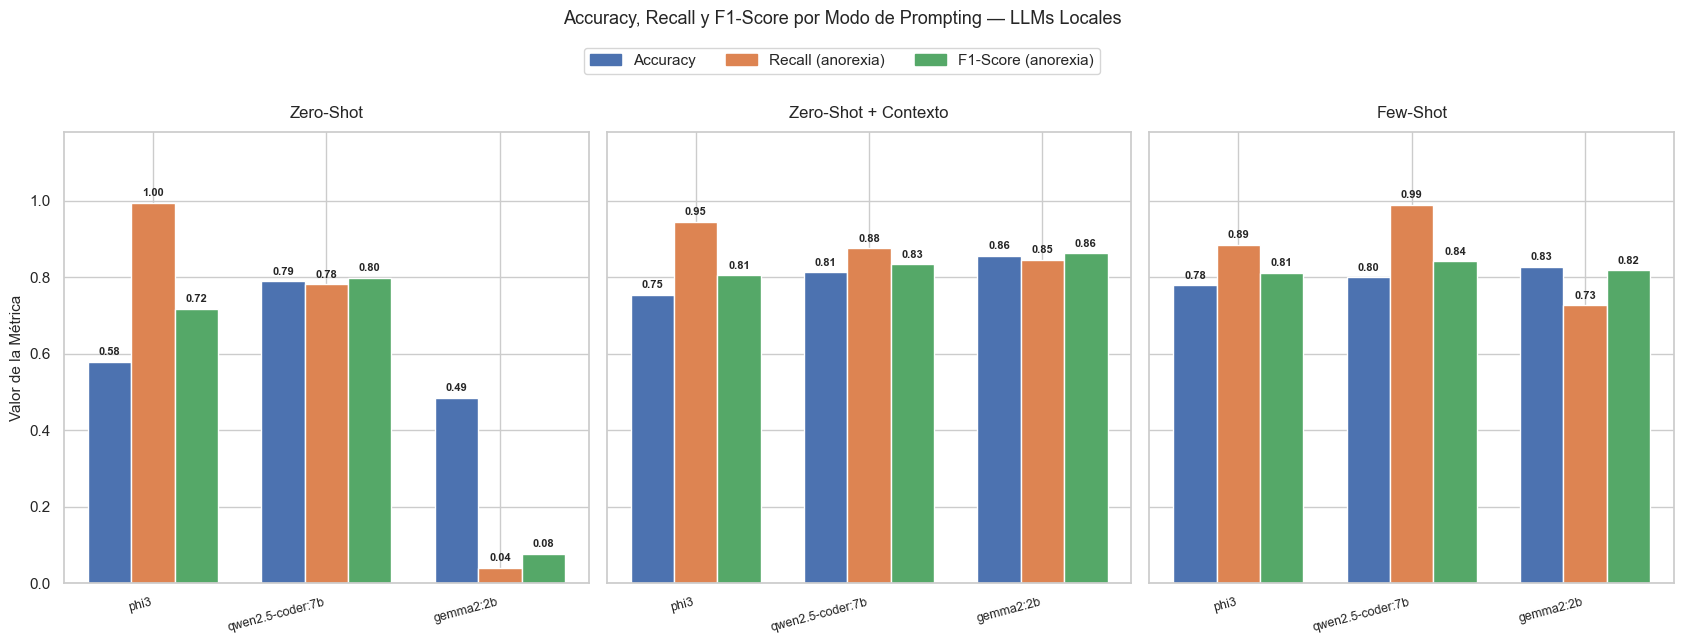

In [7]:
# Gráficas de métricas por modo (un subplot por modo)
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)

for ax, modo in zip(axes, MODOS):
    acc_v = [metricas[modo][m]['accuracy'] for m in MODELOS]
    rec_v = [metricas[modo][m]['recall']   for m in MODELOS]
    f1_v  = [metricas[modo][m]['f1']       for m in MODELOS]

    x = np.arange(len(MODELOS))
    w = 0.25
    b1 = ax.bar(x - w, acc_v, w, label='Accuracy', color='#4C72B0')
    b2 = ax.bar(x,     rec_v, w, label='Recall',   color='#DD8452')
    b3 = ax.bar(x + w, f1_v,  w, label='F1-Score', color='#55A868')

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.012,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8, weight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(MODELOS, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.18)
    ax.set_title(ETIQUETAS_MODO[modo], fontsize=12, pad=10)
    if ax == axes[0]:
        ax.set_ylabel('Valor de la Métrica', fontsize=11)

handles = [
    mpatches.Patch(color='#4C72B0', label='Accuracy'),
    mpatches.Patch(color='#DD8452', label='Recall (anorexia)'),
    mpatches.Patch(color='#55A868', label='F1-Score (anorexia)'),
]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.02), frameon=True)
fig.suptitle('Accuracy, Recall y F1-Score por Modo de Prompting — LLMs Locales',
             fontsize=13, y=1.07)
plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/metricas_por_modo.png', dpi=150, bbox_inches='tight')
plt.show()

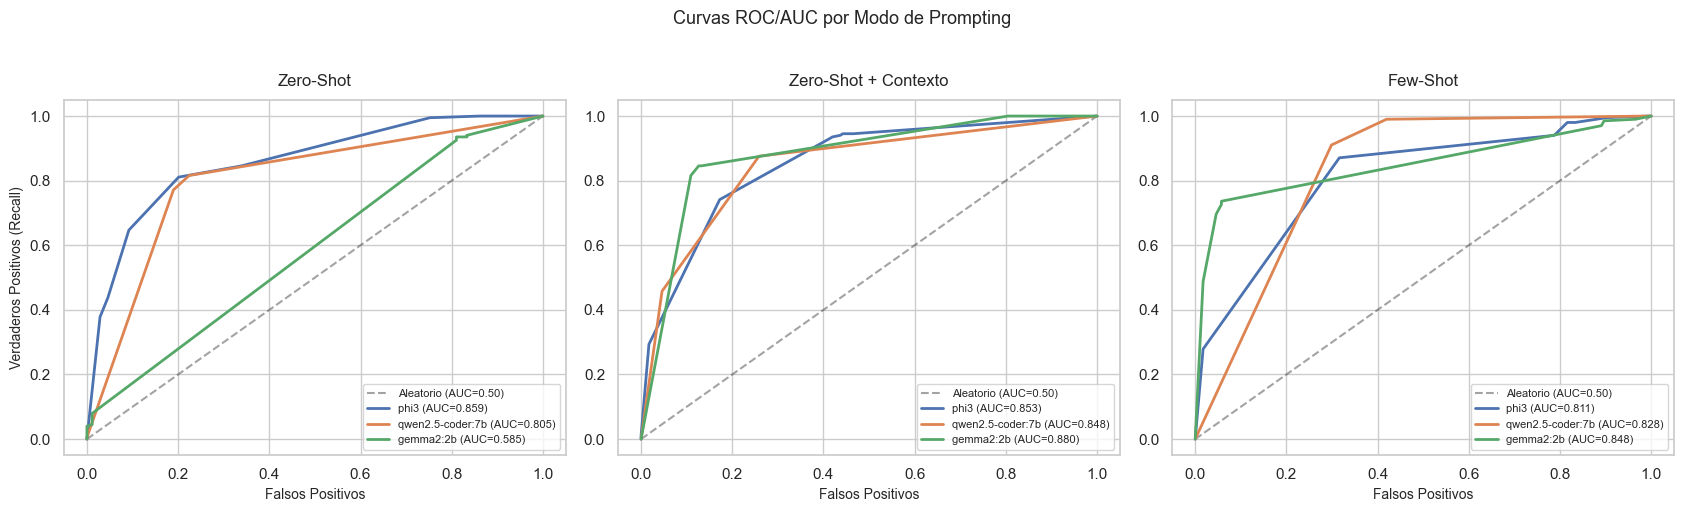

In [8]:
# Curvas ROC/AUC por modo (un subplot por modo)
colores_modelo = {'phi3': '#4C72B0', 'qwen2.5-coder:7b': '#DD8452', 'gemma2:2b': '#55A868'}
estilos_modo   = {'zero_shot': '-', 'zero_shot_ctx': '--', 'few_shot': ':'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, modo in zip(axes, MODOS):
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio (AUC=0.50)')
    for modelo in MODELOS:
        m = metricas[modo][modelo]
        y_bin = np.where(m['y_true'] == 'anorexia', 1, 0)
        fpr, tpr, _ = roc_curve(y_bin, m['y_prob'])
        score = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colores_modelo[modelo], linewidth=2,
                label=f'{modelo} (AUC={score:.3f})')
    ax.set_title(ETIQUETAS_MODO[modo], fontsize=12, pad=10)
    ax.set_xlabel('Falsos Positivos', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('Verdaderos Positivos (Recall)', fontsize=10)
    ax.legend(loc='lower right', fontsize=8)

fig.suptitle('Curvas ROC/AUC por Modo de Prompting', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/auc_por_modo.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparativa Global: Mejores LLMs vs Transformer NLI

Se toma el **mejor modo por modelo** (el modo que produjo el F1 más alto) y se compara contra los enfoques NLI supervisados del proyecto.

Métricas NLI extraídas de `ClasificadorNLI.ipynb` y `ClasificadorNLI+AG.ipynb` sobre el **mismo test set de 375 tweets**.

In [9]:
# Métricas de referencia NLI (mismo test set: 375 tweets)
referencia_nli = {
    "NLI Puro + RF":  {'accuracy': 0.776, 'recall': 0.800, 'f1': 0.790},
    "NLI + AG + RF":  {'accuracy': 0.787, 'recall': 0.851, 'f1': 0.810},
}

filas_todas = []
for modo in MODOS:
    for modelo in MODELOS:
        m = metricas[modo][modelo]
        filas_todas.append((
            modelo, ETIQUETAS_MODO[modo],
            f"{m['accuracy']:.3f}",
            f"{m['recall']:.3f}",
            f"{m['f1']:.3f}"
        ))
for nombre, v in referencia_nli.items():
    filas_todas.append((
        nombre, 'NLI Transformer',
        f"{v['accuracy']:.3f}",
        f"{v['recall']:.3f}",
        f"{v['f1']:.3f}"
    ))
filas_todas.sort(key=lambda x: float(x[4]), reverse=True)

imprimir_tabla(
    filas_todas,
    ['Modelo', 'Modo / Enfoque', 'Accuracy', 'Recall', 'F1'],
    titulo='Comparativa completa: LLMs (3 modos) vs Transformer NLI  |  Test set: 375 tweets'
)

print("\nNota: Recall es la métrica más crítica en detección clínica (falso negativo = caso no detectado).")


────────────────────────────────────────────────────────────────────────────────────
  Comparativa completa: LLMs (3 modos) vs Transformer NLI  |  Test set: 375 tweets
────────────────────────────────────────────────────────────────────────────────────
┌──────────────────┬──────────────────────┬──────────┬────────┬───────┐
│ Modelo           │ Modo / Enfoque       │ Accuracy │ Recall │ F1    │
├──────────────────┼──────────────────────┼──────────┼────────┼───────┤
│ gemma2:2b        │ Zero-Shot + Contexto │ 0.856    │ 0.846  │ 0.863 │
├──────────────────┼──────────────────────┼──────────┼────────┼───────┤
│ qwen2.5-coder:7b │ Few-Shot             │ 0.800    │ 0.990  │ 0.841 │
├──────────────────┼──────────────────────┼──────────┼────────┼───────┤
│ qwen2.5-coder:7b │ Zero-Shot + Contexto │ 0.813    │ 0.876  │ 0.834 │
├──────────────────┼──────────────────────┼──────────┼────────┼───────┤
│ gemma2:2b        │ Few-Shot             │ 0.827    │ 0.726  │ 0.818 │
├──────────────────┼──────

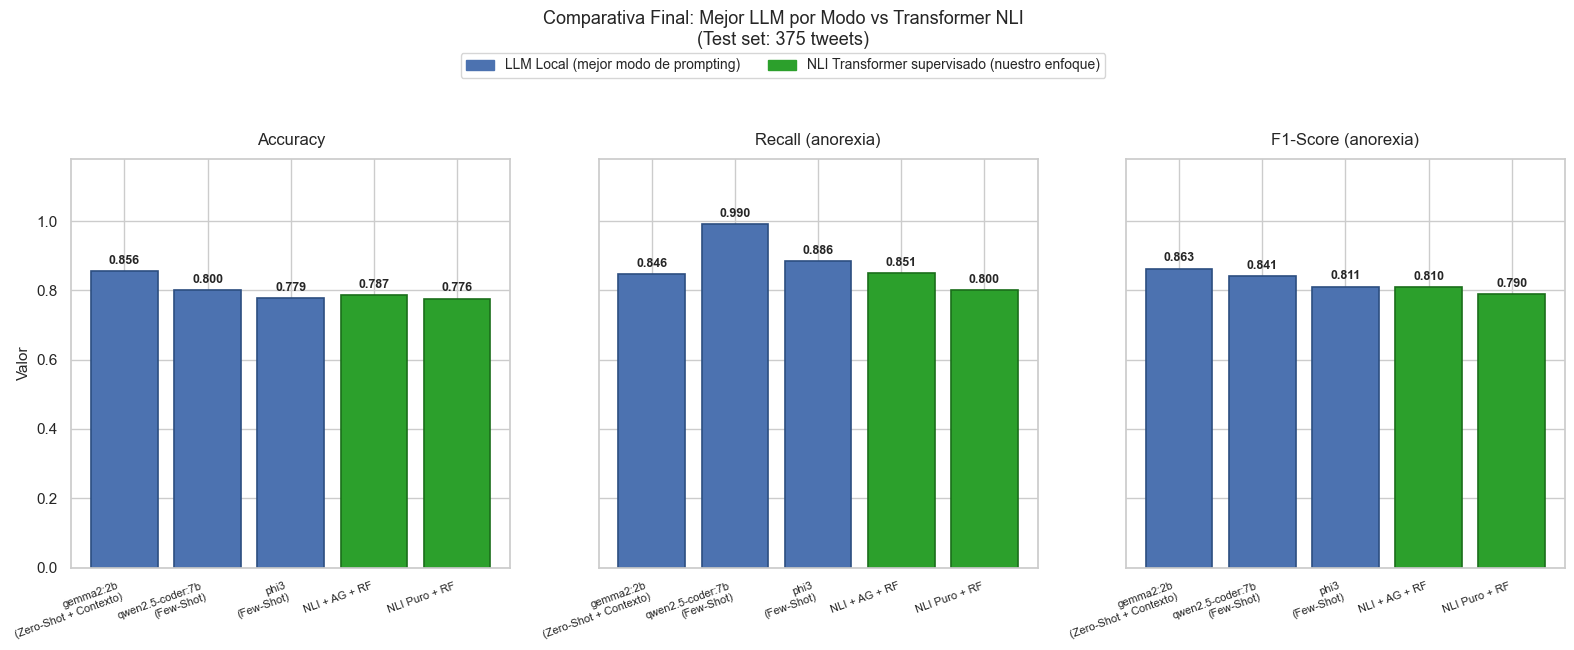

In [10]:
# Gráfica: mejor modo por modelo LLM vs NLI
filas_best = []
for modelo in MODELOS:
    mejor_modo = max(MODOS, key=lambda modo: metricas[modo][modelo]['f1'])
    m = metricas[mejor_modo][modelo]
    filas_best.append({
        'Etiqueta': f"{modelo}\n({ETIQUETAS_MODO[mejor_modo]})",
        'Enfoque':  'LLM (mejor modo)',
        'Accuracy': m['accuracy'],
        'Recall':   m['recall'],
        'F1':       m['f1'],
    })

for nombre, v in referencia_nli.items():
    filas_best.append({
        'Etiqueta': nombre,
        'Enfoque':  'NLI Transformer',
        'Accuracy': v['accuracy'],
        'Recall':   v['recall'],
        'F1':       v['f1'],
    })

df_best = pd.DataFrame(filas_best).sort_values('F1', ascending=False).reset_index(drop=True)

color_mapa  = {'LLM (mejor modo)': '#4C72B0', 'NLI Transformer': '#2ca02c'}
borde_mapa  = {'LLM (mejor modo)': '#2c4e80', 'NLI Transformer': '#1a6e1a'}
n = len(df_best)
x = np.arange(n)

metricas_comp = [
    ('Accuracy', df_best['Accuracy'].tolist()),
    ('Recall (anorexia)', df_best['Recall'].tolist()),
    ('F1-Score (anorexia)', df_best['F1'].tolist()),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, (titulo, vals) in zip(axes, metricas_comp):
    cs = [color_mapa[e] for e in df_best['Enfoque']]
    bs = [borde_mapa[e] for e in df_best['Enfoque']]
    bars = ax.bar(x, vals, color=cs, edgecolor=bs, linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, weight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_best['Etiqueta'].tolist(), rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, 1.18)
    ax.set_title(titulo, fontsize=12, pad=10)
    if ax == axes[0]:
        ax.set_ylabel('Valor', fontsize=11)

leyenda = [
    mpatches.Patch(color='#4C72B0', label='LLM Local (mejor modo de prompting)'),
    mpatches.Patch(color='#2ca02c', label='NLI Transformer supervisado (nuestro enfoque)'),
]
fig.legend(handles=leyenda, loc='upper center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, 1.02), frameon=True)
fig.suptitle(
    'Comparativa Final: Mejor LLM por Modo vs Transformer NLI\n(Test set: 375 tweets)',
    fontsize=13, y=1.08
)
plt.tight_layout()
plt.savefig(f'{CACHE_DIR}/comparativa_final.png', dpi=150, bbox_inches='tight')
plt.show()